# Detección y clasificación de bloqueos de rama en ECG

Este notebook implementa, en el mismo orden que el anteproyecto, el
pipeline completo para clasificar registros en `NORM`, `RBBB` y
`LBBB`.

El flujo utilizado es:

1. Carga y armonización de PTB-XL, CPSC y Chapman-Shaoxing.
2. Remuestreo a 100 Hz y filtrado Butterworth de 0,5 a 40 Hz.
3. Detección de QRS con Pan-Tompkins.
4. Segmentación adaptativa con la envolvente integrada.
5. Control de calidad y registro de exclusiones.
6. Features morfológicas, Welch y DWT Haar.
7. Comparación entre Random Forest y una red MLP.
8. Evaluación interna y validación externa.

Las celdas están pensadas para ejecutarse en orden, de arriba hacia
abajo.


## 1. Importación de librerías

**Qué hace:** Carga las herramientas necesarias para leer ECG, procesar señales, crear gráficos y entrenar modelos.

**Por qué se hace:** Centralizar las importaciones permite saber desde el comienzo qué dependencias usa el proyecto.

**Resultado esperado:** Las librerías quedan disponibles para todas las etapas posteriores.


In [1]:
from pathlib import Path
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.signal as signal
import wfdb

from scipy.integrate import trapezoid
from scipy.signal import butter, filtfilt, welch
from IPython.display import display

from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
)

np.random.seed(42)


## 2. Configuración general

**Qué hace:** Define las rutas, las tres clases finales, la frecuencia común y el tamaño del conjunto de prueba.

**Por qué se hace:** Estos valores cambian según la computadora o según si se desea una ejecución rápida o completa.

**Resultado esperado:** Todos los parámetros importantes quedan visibles en un único lugar.


In [2]:
PATH_PTBXL = Path(
    "../data/raw/"
    "ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"
)
PATH_CPSC = Path("../data/raw/Training_WFDB")
PATH_CHAPMAN = Path("../data/raw/chapman-shaoxing")

CLASES = ["NORM", "RBBB", "LBBB"]
FS_OBJETIVO = 100

# Usar 100 para una ejecución rápida. Usar None para cargar todo.
MAX_REGISTROS_POR_CLASE = 100

# Para la validación actual se entrena con PTB-XL y se prueba en CPSC.
BASE_DESARROLLO = "PTBXL"
BASE_EXTERNA = "CPSC"


## 3. Funciones comunes para armonizar las bases

**Qué hace:** Convierte etiquetas distintas a tres clases, encuentra DI/V1/V6, remuestrea y crea un formato común.

**Por qué se hace:** Las bases tienen nombres, frecuencias y estructuras diferentes; los modelos necesitan recibir datos equivalentes.

**Resultado esperado:** Cada registro queda representado por el mismo diccionario, independientemente de su base de origen.


In [3]:
def normalizar_etiqueta(etiqueta):
    texto = str(etiqueta).upper()
    clases = []

    if any(codigo in texto for codigo in ["RBBB", "CRBBB", "IRBBB", "59118001"]):
        clases.append("RBBB")
    if any(codigo in texto for codigo in ["LBBB", "CLBBB", "ILBBB", "164909002"]):
        clases.append("LBBB")
    if any(codigo in texto for codigo in ["NORM", "NORMAL", "426783006"]):
        clases.append("NORM")
    if texto.strip() == "SR":
        clases.append("NORM")

    # Se excluyen etiquetas ambiguas con más de una clase objetivo.
    return clases[0] if len(clases) == 1 else None


def indices_derivaciones(nombres):
    nombres = [str(nombre).upper().strip() for nombre in nombres]
    if not all(nombre in nombres for nombre in ["I", "V1", "V6"]):
        return None
    return [nombres.index("I"), nombres.index("V1"), nombres.index("V6")]


def remuestrear(senal, fs_original):
    if int(fs_original) == FS_OBJETIVO:
        return np.asarray(senal)
    return signal.resample_poly(
        senal, FS_OBJETIVO, int(fs_original), axis=0
    )


def crear_registro(clave, patient_id, base, clase, senales):
    senales = np.asarray(senales, dtype=float)
    return {
        "id_registro": clave,
        "patient_id": patient_id,
        "base": base,
        "clase_clinica": clase,
        "fs": FS_OBJETIVO,
        "senal_I": senales[:, 0],
        "senal_v1": senales[:, 1],
        "senal_v6": senales[:, 2],
    }


def seleccionar_ids(ids, maximo, semilla=42):
    ids = np.asarray(ids)
    if maximo is None or len(ids) <= maximo:
        return ids
    rng = np.random.default_rng(semilla)
    return rng.choice(ids, size=maximo, replace=False)


## 4. Carga de PTB-XL

**Qué hace:** Lee los metadatos de PTB-XL, agrupa bloqueos completos e incompletos y conserva DI, V1 y V6.

**Por qué se hace:** PTB-XL es la base histórica del proyecto y será utilizada para entrenamiento y evaluación interna.

**Resultado esperado:** Se obtiene un diccionario de registros PTB-XL armonizados a 100 Hz.


In [4]:
def clase_ptbxl(codigos):
    codigos = set(codigos.keys())
    clases = []

    if codigos & {"RBBB", "CRBBB", "IRBBB"}:
        clases.append("RBBB")
    if codigos & {"LBBB", "CLBBB", "ILBBB"}:
        clases.append("LBBB")
    if "NORM" in codigos:
        clases.append("NORM")

    # Una etiqueta simultánea RBBB/LBBB no tiene una clase única.
    return clases[0] if len(clases) == 1 else None


def cargar_ptbxl(path):
    dataset = {}
    if not path.exists():
        print("No se encontró PTB-XL:", path.resolve())
        return dataset

    metadata = pd.read_csv(path / "ptbxl_database.csv", index_col="ecg_id")
    metadata["scp_codes"] = metadata["scp_codes"].apply(ast.literal_eval)
    metadata["clase_clinica"] = metadata["scp_codes"].apply(clase_ptbxl)

    for clase in CLASES:
        ids = metadata.index[metadata["clase_clinica"] == clase]
        ids = seleccionar_ids(ids, MAX_REGISTROS_POR_CLASE)

        for ecg_id in ids:
            fila = metadata.loc[ecg_id]
            ruta = path / fila["filename_lr"]
            registro = wfdb.rdrecord(str(ruta), channels=[0, 6, 11])
            clave = f"PTBXL_{int(ecg_id):06d}"

            dataset[clave] = crear_registro(
                clave=clave,
                patient_id=fila["patient_id"],
                base="PTBXL",
                clase=clase,
                senales=registro.p_signal,
            )

        print(f"PTB-XL {clase}: {len(ids)} registros")

    return dataset


dataset_ptbxl = cargar_ptbxl(PATH_PTBXL)


PTB-XL NORM: 100 registros


PTB-XL RBBB: 100 registros


PTB-XL LBBB: 100 registros


## 5. Carga de CPSC

**Qué hace:** Lee los diagnósticos guardados en los encabezados WFDB, selecciona DI/V1/V6 y remuestrea de 500 a 100 Hz.

**Por qué se hace:** CPSC aporta una población independiente y se reserva como validación externa.

**Resultado esperado:** Se obtiene un diccionario CPSC con la misma estructura que PTB-XL.


In [5]:
def diagnostico_header(comentarios):
    for comentario in comentarios:
        if str(comentario).startswith("Dx:"):
            return str(comentario).replace("Dx:", "").strip()
    return ""


def cargar_cpsc(path):
    dataset = {}
    contador = {clase: 0 for clase in CLASES}

    if not path.exists():
        print("No se encontró CPSC:", path.resolve())
        return dataset

    for archivo in sorted(path.glob("*.hea")):
        nombre = archivo.stem
        ruta = path / nombre
        header = wfdb.rdheader(str(ruta))
        clase = normalizar_etiqueta(diagnostico_header(header.comments))

        if clase is None:
            continue
        if (
            MAX_REGISTROS_POR_CLASE is not None
            and contador[clase] >= MAX_REGISTROS_POR_CLASE
        ):
            continue

        indices = indices_derivaciones(header.sig_name)
        if indices is None:
            continue

        registro = wfdb.rdrecord(str(ruta), channels=indices)
        senales = remuestrear(registro.p_signal, registro.fs)
        clave = f"CPSC_{nombre}"

        dataset[clave] = crear_registro(
            clave=clave,
            patient_id=nombre,
            base="CPSC",
            clase=clase,
            senales=senales,
        )
        contador[clase] += 1

        if (
            MAX_REGISTROS_POR_CLASE is not None
            and all(valor >= MAX_REGISTROS_POR_CLASE for valor in contador.values())
        ):
            break

    for clase, cantidad in contador.items():
        print(f"CPSC {clase}: {cantidad} registros")
    return dataset


dataset_cpsc = cargar_cpsc(PATH_CPSC)


CPSC NORM: 100 registros
CPSC RBBB: 100 registros
CPSC LBBB: 100 registros


## 6. Carga opcional de Chapman-Shaoxing

**Qué hace:** Busca una versión WFDB de Chapman y la carga con el mismo procedimiento que CPSC.

**Por qué se hace:** El anteproyecto incluye tres bases; si Chapman todavía no está descargada, el notebook debe continuar sin fallar.

**Resultado esperado:** Se cargan los registros compatibles o se informa claramente que la base está pendiente.


In [6]:
def cargar_chapman(path):
    dataset = {}
    contador = {clase: 0 for clase in CLASES}

    if not path.exists():
        print("Chapman-Shaoxing todavía no está disponible.")
        return dataset

    archivos = sorted(path.rglob("*.hea"))
    if not archivos:
        print("Chapman existe, pero no se encontraron archivos WFDB (.hea).")
        return dataset

    for archivo in archivos:
        nombre = archivo.stem
        ruta = archivo.with_suffix("")
        header = wfdb.rdheader(str(ruta))
        clase = normalizar_etiqueta(diagnostico_header(header.comments))

        if clase is None:
            continue
        if (
            MAX_REGISTROS_POR_CLASE is not None
            and contador[clase] >= MAX_REGISTROS_POR_CLASE
        ):
            continue

        indices = indices_derivaciones(header.sig_name)
        if indices is None:
            continue

        registro = wfdb.rdrecord(str(ruta), channels=indices)
        senales = remuestrear(registro.p_signal, registro.fs)
        clave = f"CHAPMAN_{nombre}"

        dataset[clave] = crear_registro(
            clave=clave,
            patient_id=nombre,
            base="CHAPMAN",
            clase=clase,
            senales=senales,
        )
        contador[clase] += 1

    for clase, cantidad in contador.items():
        print(f"Chapman {clase}: {cantidad} registros")
    return dataset


dataset_chapman = cargar_chapman(PATH_CHAPMAN)


Chapman-Shaoxing todavía no está disponible.


## 7. Unión y resumen del dataset

**Qué hace:** Combina las bases y cuenta cuántos registros hay por origen y por clase.

**Por qué se hace:** Antes de procesar señales es necesario comprobar que la distribución coincide con lo esperado.

**Resultado esperado:** Se crea `dataset_proyecto`, que será utilizado por todo el pipeline.


In [7]:
dataset_proyecto = {
    **dataset_ptbxl,
    **dataset_cpsc,
    **dataset_chapman,
}

resumen_dataset = pd.DataFrame([
    {
        "base": paciente["base"],
        "clase_clinica": paciente["clase_clinica"],
    }
    for paciente in dataset_proyecto.values()
])

print("Total de registros:", len(dataset_proyecto))
display(pd.crosstab(
    resumen_dataset["base"],
    resumen_dataset["clase_clinica"],
    margins=True,
))


Total de registros: 600


clase_clinica,LBBB,NORM,RBBB,All
base,,,,
CPSC,100,100,100,300
PTBXL,100,100,100,300
All,200,200,200,600


## 8. Inspección inicial en tiempo y frecuencia

**Qué hace:** Muestra DI de un registro y calcula su densidad espectral de potencia mediante Welch.

**Por qué se hace:** La inspección permite observar deriva de línea de base, ruido y contenido frecuencial antes de filtrar.

**Resultado esperado:** Se obtiene una primera comprobación visual de la señal cruda.


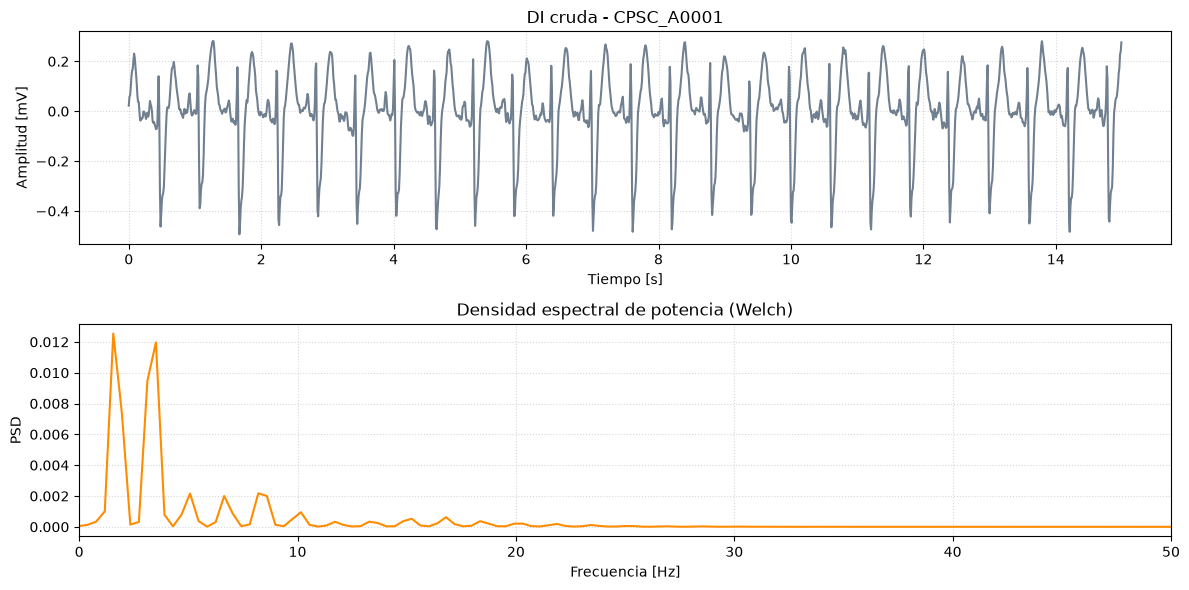

In [8]:
clave_ejemplo = sorted(dataset_proyecto.keys())[0]
paciente_ejemplo = dataset_proyecto[clave_ejemplo]
fs = paciente_ejemplo["fs"]
senal = paciente_ejemplo["senal_I"]
tiempo = np.arange(len(senal)) / fs

frecuencias, psd = welch(
    senal,
    fs=fs,
    nperseg=min(256, len(senal)),
)

fig, ejes = plt.subplots(2, 1, figsize=(12, 6))
ejes[0].plot(tiempo, senal, color="slategray")
ejes[0].set_title(f"DI cruda - {clave_ejemplo}")
ejes[0].set_xlabel("Tiempo [s]")
ejes[0].set_ylabel("Amplitud [mV]")

ejes[1].plot(frecuencias, psd, color="darkorange")
ejes[1].set_xlim(0, 50)
ejes[1].set_title("Densidad espectral de potencia (Welch)")
ejes[1].set_xlabel("Frecuencia [Hz]")
ejes[1].set_ylabel("PSD")

for eje in ejes:
    eje.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


## 9. Filtrado Butterworth

**Qué hace:** Aplica un pasa-banda de 0,5 a 40 Hz con `filtfilt` a DI, V1 y V6.

**Por qué se hace:** El filtro reduce deriva de línea de base y ruido de alta frecuencia sin introducir desplazamiento de fase.

**Resultado esperado:** Cada paciente incorpora tres señales limpias listas para detectar QRS.


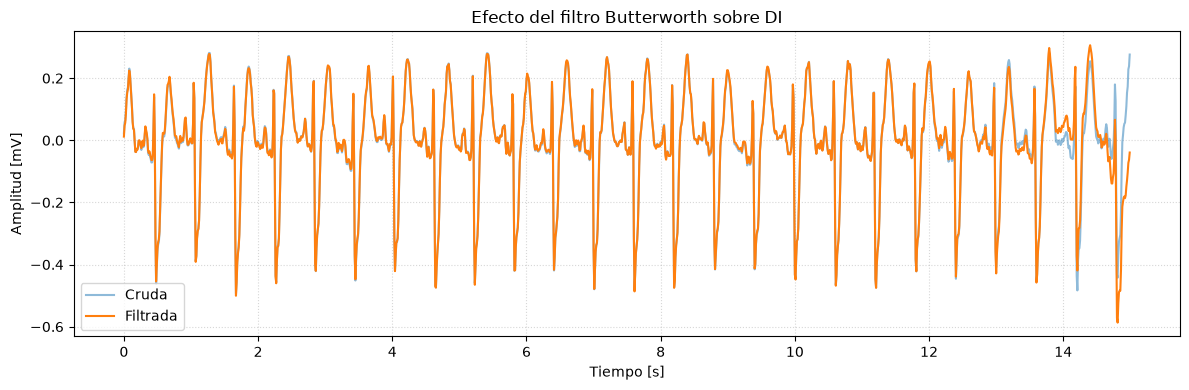

Registros filtrados: 600


In [9]:
def filtrar_ecg(senal, fs):
    nyquist = fs / 2
    b, a = butter(
        4,
        [0.5 / nyquist, 40 / nyquist],
        btype="bandpass",
    )
    return filtfilt(b, a, senal)


for paciente in dataset_proyecto.values():
    fs = paciente["fs"]
    paciente["senal_I_limpia"] = filtrar_ecg(paciente["senal_I"], fs)
    paciente["senal_v1_limpia"] = filtrar_ecg(paciente["senal_v1"], fs)
    paciente["senal_v6_limpia"] = filtrar_ecg(paciente["senal_v6"], fs)


# Comparación sencilla antes y después del filtro.
paciente_ejemplo = dataset_proyecto[clave_ejemplo]
tiempo = np.arange(len(paciente_ejemplo["senal_I"])) / paciente_ejemplo["fs"]

plt.figure(figsize=(12, 4))
plt.plot(tiempo, paciente_ejemplo["senal_I"], alpha=0.5, label="Cruda")
plt.plot(tiempo, paciente_ejemplo["senal_I_limpia"], label="Filtrada")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [mV]")
plt.title("Efecto del filtro Butterworth sobre DI")
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

print("Registros filtrados:", len(dataset_proyecto))


## 10. Etapas de Pan-Tompkins

**Qué hace:** Calcula pasa-banda QRS, derivada, cuadrado, envolvente integrada y un umbral adaptativo.

**Por qué se hace:** Pan-Tompkins transforma cada QRS en una joroba de energía que resulta más fácil de detectar que la señal cruda.

**Resultado esperado:** Se dispone de una función que devuelve tanto los picos candidatos como todos los perfiles intermedios.


In [10]:
def perfil_pan_tompkins(senal, fs, ancho_integracion_ms=180):
    # 1. Pasa-banda específico para QRS: 5 a 15 Hz.
    nyquist = fs / 2
    b, a = butter(
        2,
        [5 / nyquist, 15 / nyquist],
        btype="bandpass",
    )
    pasabanda = filtfilt(b, a, senal)

    # 2. Derivada: resalta pendientes rápidas.
    kernel = np.array([-1, -2, 0, 2, 1]) / (8 / fs)
    derivada = np.convolve(pasabanda, kernel, mode="same")

    # 3. Cuadrado: convierte la pendiente en energía positiva.
    cuadrado = derivada ** 2

    # 4. Integración: crea una joroba por QRS.
    muestras = max(1, int(ancho_integracion_ms * fs / 1000))
    ventana = np.ones(muestras) / muestras
    integrada = np.convolve(cuadrado, ventana, mode="same")

    return pasabanda, derivada, cuadrado, integrada


def detectar_picos_adaptativos(integrada, fs):
    # Versión sencilla del umbral adaptativo SPKI/NPKI.
    candidatos, _ = signal.find_peaks(
        integrada,
        distance=int(0.30 * fs),
    )
    if len(candidatos) == 0:
        return np.array([], dtype=int)

    inicial = integrada[:min(len(integrada), int(2 * fs))]
    nivel_senal = float(np.max(inicial)) * 0.25
    nivel_ruido = float(np.mean(inicial)) * 0.50
    aceptados = []

    for pico in candidatos:
        umbral = nivel_ruido + 0.25 * (nivel_senal - nivel_ruido)
        amplitud = float(integrada[pico])

        if amplitud > umbral:
            aceptados.append(int(pico))
            nivel_senal = 0.125 * amplitud + 0.875 * nivel_senal
        else:
            nivel_ruido = 0.125 * amplitud + 0.875 * nivel_ruido

    return np.asarray(aceptados, dtype=int)


## 11. Detección y segmentación adaptativa unificadas

**Qué hace:** Usa una sola envolvente para detectar picos, corregir su posición en DI y delimitar dinámicamente cada segmento.

**Por qué se hace:** Compartir la envolvente evita que detección y segmentación utilicen parámetros diferentes; los límites variables no cortan QRS anchos.

**Resultado esperado:** Cada paciente recibe sus picos R, su envolvente y los segmentos sincronizados de DI, V1 y V6.


In [11]:
def limites_por_envolvente(integrada, picos, nivel_relativo=0.15):
    limites = []

    for i, pico in enumerate(picos):
        izquierda = 0 if i == 0 else (picos[i - 1] + pico) // 2
        derecha = (
            len(integrada) - 1
            if i == len(picos) - 1
            else (pico + picos[i + 1]) // 2
        )

        contexto = integrada[izquierda:derecha + 1]
        base = float(np.percentile(contexto, 10))
        umbral = base + nivel_relativo * (integrada[pico] - base)

        antes = np.flatnonzero(integrada[izquierda:pico + 1] <= umbral)
        despues = np.flatnonzero(integrada[pico:derecha + 1] <= umbral)

        inicio = izquierda if len(antes) == 0 else izquierda + antes[-1] + 1
        fin = derecha if len(despues) == 0 else pico + despues[0] - 1
        limites.append((int(inicio), int(fin), base, float(umbral)))

    return limites


def detectar_y_segmentar(paciente, nivel_relativo=0.15):
    fs = paciente["fs"]
    senal_i = paciente["senal_I_limpia"]
    pasabanda, derivada, cuadrado, integrada = perfil_pan_tompkins(
        senal_i, fs
    )
    picos_integrada = detectar_picos_adaptativos(integrada, fs)

    # Ubicar el extremo real del QRS cerca de cada joroba.
    radio = int(0.15 * fs)
    picos_r = []
    for pico in picos_integrada:
        inicio = max(0, pico - radio)
        fin = min(len(pasabanda), pico + radio + 1)
        extremo = np.argmax(np.abs(pasabanda[inicio:fin]))
        picos_r.append(inicio + int(extremo))
    picos_r = np.asarray(picos_r, dtype=int)

    limites = limites_por_envolvente(integrada, picos_integrada)
    senales = np.column_stack([
        paciente["senal_I_limpia"],
        paciente["senal_v1_limpia"],
        paciente["senal_v6_limpia"],
    ])

    segmentos = []
    for pico_env, pico_r, (inicio, fin, base, umbral) in zip(
        picos_integrada, picos_r, limites
    ):
        inicio = max(0, min(inicio, int(pico_r)))
        fin = min(len(senales) - 1, max(fin, int(pico_r)))
        segmentos.append({
            "senal_qrs": senales[inicio:fin + 1],
            "inicio": inicio,
            "fin": fin,
            "indice_R": int(pico_r),
            "indice_R_segmento": int(pico_r - inicio),
            "pico_envolvente": int(pico_env),
            "umbral_envolvente": umbral,
            # Es el ancho delimitado por la envolvente integrada.
            # No se interpreta como una medición clínica exacta del QRS.
            "ancho_envolvente_ms": (fin - inicio + 1) * 1000 / fs,
        })

    paciente["indices_ondas_r"] = picos_r
    paciente["envolvente_qrs"] = integrada
    paciente["segmentos_qrs"] = segmentos


for paciente in dataset_proyecto.values():
    detectar_y_segmentar(paciente)

total_qrs = sum(
    len(paciente["segmentos_qrs"])
    for paciente in dataset_proyecto.values()
)
print("QRS segmentados:", total_qrs)


QRS segmentados: 9517


## 12. Visualización de la segmentación

**Qué hace:** Grafica todos los segmentos QRS y la envolvente integrada de un paciente.

**Por qué se hace:** La inspección visual comprueba que las zonas verdes rodean cada QRS y que el umbral sigue la energía del complejo.

**Resultado esperado:** Se obtiene una figura de control antes de extraer características.


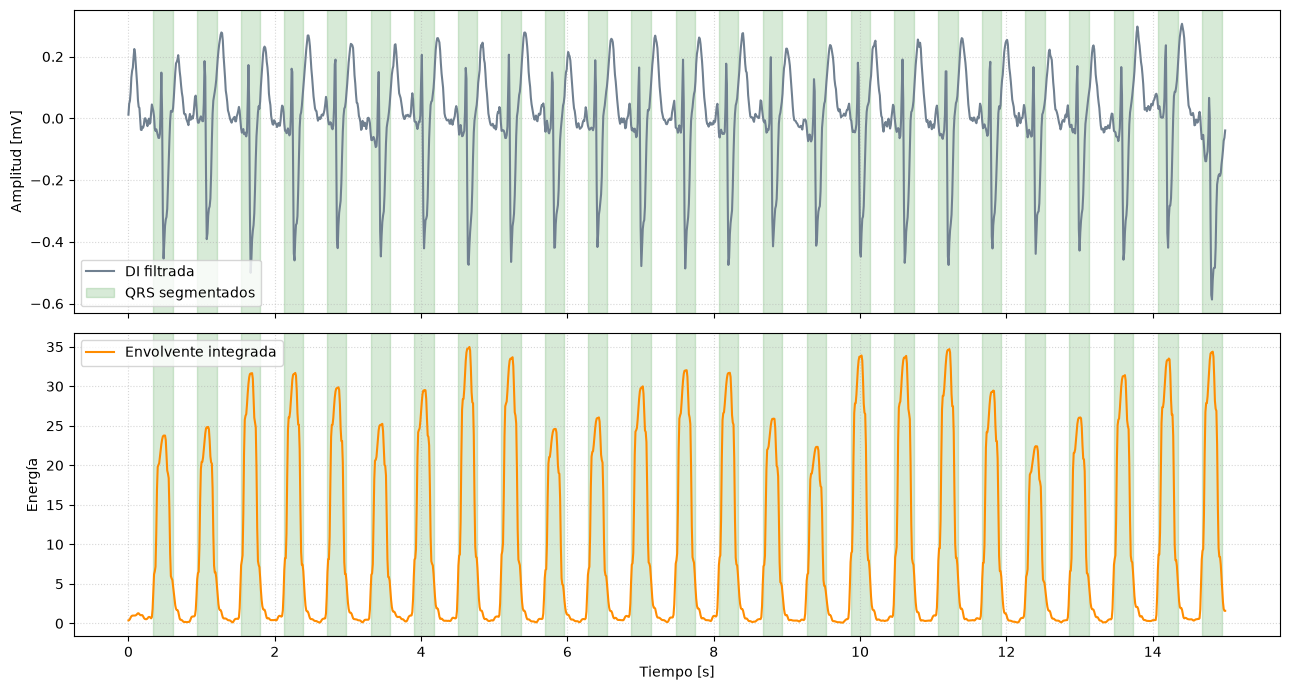

QRS del paciente mostrado: 25


In [12]:
paciente_ejemplo = dataset_proyecto[clave_ejemplo]
fs = paciente_ejemplo["fs"]
tiempo = np.arange(len(paciente_ejemplo["senal_I_limpia"])) / fs

fig, ejes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
ejes[0].plot(
    tiempo,
    paciente_ejemplo["senal_I_limpia"],
    color="slategray",
    label="DI filtrada",
)
ejes[1].plot(
    tiempo,
    paciente_ejemplo["envolvente_qrs"],
    color="darkorange",
    label="Envolvente integrada",
)

for i, segmento in enumerate(paciente_ejemplo["segmentos_qrs"]):
    inicio = tiempo[segmento["inicio"]]
    fin = tiempo[segmento["fin"]]
    etiqueta = "QRS segmentados" if i == 0 else None
    ejes[0].axvspan(
        inicio, fin, color="forestgreen", alpha=0.18, label=etiqueta
    )
    ejes[1].axvspan(inicio, fin, color="forestgreen", alpha=0.18)

ejes[0].set_ylabel("Amplitud [mV]")
ejes[1].set_ylabel("Energía")
ejes[1].set_xlabel("Tiempo [s]")
ejes[0].legend()
ejes[1].legend()
for eje in ejes:
    eje.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

print("QRS del paciente mostrado:", len(paciente_ejemplo["segmentos_qrs"]))


## 13. Control de calidad y exclusiones

**Qué hace:** Evalúa valores inválidos, señal plana, saturación, SNR estimada, cantidad de QRS e inestabilidad extrema de los intervalos RR.

**Por qué se hace:** El anteproyecto exige justificar cada descarte; por eso se conserva una fila con el motivo de inclusión o exclusión.

**Resultado esperado:** Se crean `dataset_calidad` y `reporte_exclusiones` sin borrar los datos originales.


In [13]:
def fraccion_plana(senal, fs):
    desvio_total = np.std(senal)
    if desvio_total == 0:
        return 1.0

    ventana = int(fs)
    muestras_planas = 0
    for inicio in range(0, len(senal), ventana):
        tramo = senal[inicio:inicio + ventana]
        if np.std(tramo) < 0.01 * desvio_total:
            muestras_planas += len(tramo)
    return muestras_planas / len(senal)


def fraccion_saturada(senal):
    extremos = (senal == np.min(senal)) | (senal == np.max(senal))
    return float(np.mean(extremos))


def snr_estimada(senal_cruda, senal_limpia):
    ruido = senal_cruda - senal_limpia
    potencia_senal = np.var(senal_limpia)
    potencia_ruido = np.var(ruido)
    return float(10 * np.log10(
        (potencia_senal + 1e-12) / (potencia_ruido + 1e-12)
    ))


dataset_calidad = {}
filas_exclusion = []

for clave, paciente in dataset_proyecto.items():
    crudas = [
        paciente["senal_I"],
        paciente["senal_v1"],
        paciente["senal_v6"],
    ]
    limpias = [
        paciente["senal_I_limpia"],
        paciente["senal_v1_limpia"],
        paciente["senal_v6_limpia"],
    ]
    razones = []

    if any(np.any(~np.isfinite(senal)) for senal in crudas + limpias):
        razones.append("NaN o infinito")

    plano = max(fraccion_plana(senal, paciente["fs"]) for senal in crudas)
    saturado = max(fraccion_saturada(senal) for senal in crudas)
    snr = min(
        snr_estimada(cruda, limpia)
        for cruda, limpia in zip(crudas, limpias)
    )

    if plano > 0.20:
        razones.append("señal plana > 20%")
    if saturado > 0.20:
        razones.append("saturación > 20%")
    if snr < 0:
        razones.append("SNR < 0 dB")

    picos = paciente["indices_ondas_r"]
    cv_rr = np.nan
    if len(picos) < 3:
        razones.append("menos de 3 QRS")
    else:
        rr = np.diff(picos) / paciente["fs"]
        cv_rr = float(np.std(rr) / np.mean(rr))
        if cv_rr > 0.80:
            razones.append("intervalos RR extremadamente inestables")

    incluido = len(razones) == 0
    if incluido:
        dataset_calidad[clave] = paciente

    filas_exclusion.append({
        "id_registro": clave,
        "patient_id": paciente["patient_id"],
        "base": paciente["base"],
        "clase_clinica": paciente["clase_clinica"],
        "estado": "Incluido" if incluido else "Excluido",
        "motivo": "Sin exclusión" if incluido else "; ".join(razones),
        "fraccion_plana": plano,
        "fraccion_saturada": saturado,
        "snr_min_db": snr,
        "cantidad_qrs": len(picos),
        "cv_rr": cv_rr,
    })

reporte_exclusiones = pd.DataFrame(filas_exclusion)

print("Registros originales:", len(dataset_proyecto))
print("Registros incluidos :", len(dataset_calidad))
print("Registros excluidos :", len(dataset_proyecto) - len(dataset_calidad))
display(reporte_exclusiones["estado"].value_counts().to_frame("cantidad"))
display(
    reporte_exclusiones.query("estado == 'Excluido'")["motivo"]
    .value_counts()
    .to_frame("cantidad_por_motivo")
)


Registros originales: 600
Registros incluidos : 548
Registros excluidos : 52


,cantidad
estado,
Incluido,548
Excluido,52


,cantidad_por_motivo
motivo,
SNR < 0 dB,51
intervalos RR extremadamente inestables,1


## 14. Validación de Pan-Tompkins contra XQRS

**Qué hace:** Compara Pan-Tompkins con XQRS en DI, V1 y V6 para hasta cinco registros por base y clase, usando una tolerancia de ±100 ms.

**Por qué se hace:** Las bases disponibles no incluyen anotaciones manuales de latidos; XQRS funciona como referencia de acuerdo, no como ground truth.

**Resultado esperado:** Se obtiene sensibilidad de acuerdo, precisión de acuerdo y error temporal medio por base, clase y derivación.


In [14]:
from wfdb.processing import xqrs_detect

# Compatibilidad entre WFDB 4.1.2 y SciPy reciente.
if not hasattr(signal, "ricker"):
    def ricker_compatible(points, a):
        vector = np.arange(points) - (points - 1) / 2
        factor = 2 / (np.sqrt(3 * a) * np.pi ** 0.25)
        return factor * (1 - vector ** 2 / a ** 2) * np.exp(
            -vector ** 2 / (2 * a ** 2)
        )

    signal.ricker = ricker_compatible


def comparar_picos(picos_pan, picos_xqrs, tolerancia):
    usados = set()
    errores = []

    for pico_pan in picos_pan:
        if len(picos_xqrs) == 0:
            break
        diferencias = np.abs(picos_xqrs - pico_pan)
        indice = int(np.argmin(diferencias))
        if diferencias[indice] <= tolerancia and indice not in usados:
            usados.add(indice)
            errores.append(float(diferencias[indice]))

    tp = len(usados)
    fp = len(picos_pan) - tp
    fn = len(picos_xqrs) - tp
    return tp, fp, fn, errores


def detectar_r_validacion(senal, fs):
    pasabanda, _, _, integrada = perfil_pan_tompkins(senal, fs)
    picos_envolvente = detectar_picos_adaptativos(integrada, fs)
    radio = int(0.15 * fs)
    picos_r = []

    for pico in picos_envolvente:
        inicio = max(0, pico - radio)
        fin = min(len(pasabanda), pico + radio + 1)
        extremo = np.argmax(np.abs(pasabanda[inicio:fin]))
        picos_r.append(inicio + int(extremo))

    return np.asarray(picos_r, dtype=int)


claves_validacion = []
for base in sorted({p["base"] for p in dataset_calidad.values()}):
    for clase in CLASES:
        claves = sorted([
            clave
            for clave, paciente in dataset_calidad.items()
            if paciente["base"] == base
            and paciente["clase_clinica"] == clase
        ])
        claves_validacion.extend(claves[:5])

filas_validacion = []
for clave in claves_validacion:
    paciente = dataset_calidad[clave]
    fs = paciente["fs"]
    senales = {
        "I": paciente["senal_I_limpia"],
        "V1": paciente["senal_v1_limpia"],
        "V6": paciente["senal_v6_limpia"],
    }

    for derivacion, senal_derivacion in senales.items():
        picos_pan = detectar_r_validacion(senal_derivacion, fs)

        try:
            picos_xqrs = xqrs_detect(
                sig=senal_derivacion,
                fs=fs,
                verbose=False,
            )
        except Exception:
            continue

        tp, fp, fn, errores = comparar_picos(
            picos_pan,
            np.asarray(picos_xqrs),
            tolerancia=int(0.10 * fs),
        )

        filas_validacion.append({
            "id_registro": clave,
            "base": paciente["base"],
            "clase_clinica": paciente["clase_clinica"],
            "derivacion": derivacion,
            "sensibilidad_acuerdo": (
                tp / (tp + fn) if tp + fn else np.nan
            ),
            "precision_acuerdo": (
                tp / (tp + fp) if tp + fp else np.nan
            ),
            "error_temporal_ms": (
                np.mean(errores) * 1000 / fs if errores else np.nan
            ),
        })

reporte_validacion_pan = pd.DataFrame(filas_validacion)
print("Registros comparados:", reporte_validacion_pan["id_registro"].nunique())
print("Comparaciones registro-derivación:", len(reporte_validacion_pan))
display(
    reporte_validacion_pan.groupby(
        ["base", "clase_clinica", "derivacion"]
    )[
        [
            "sensibilidad_acuerdo",
            "precision_acuerdo",
            "error_temporal_ms",
        ]
    ].mean().round(3)
)


Registros comparados: 30
Comparaciones registro-derivación: 90


sensibilidad_acuerdo  precision_acuerdo  \
base  clase_clinica derivacion                                            
CPSC  LBBB          I                          0.958              0.982   
                    V1                         0.986              1.000   
                    V6                         0.889              0.911   
      NORM          I                          0.774              0.961   
                    V1                         0.946              0.946   
                    V6                         0.814              0.992   
      RBBB          I                          0.881              0.994   
                    V1                         0.785              0.954   
                    V6                         0.895              0.994   
PTBXL LBBB          I                          0.820              0.883   
                    V1                         1.000              1.000   
                    V6                         0.884              0.985   
      NORM          I                          0.700              0.820   
                    V1                         0.887              0.903   
                    V6                         0.985              0.974   
      RBBB          I                          0.883              0.963   
                    V1                         0.867              0.889   
                    V6                         0.896              0.976   

                                error_temporal_ms  
base  clase_clinica derivacion                     
CPSC  LBBB          I                      48.285  
                    V1                     62.507  
                    V6                     63.492  
      NORM          I                      43.295  
                    V1                     32.393  
                    V6                     28.210  
      RBBB          I                      30.002  
                    V1                     58.113  
                    V6                     23.757  
PTBXL LBBB          I                      41.475  
                    V1                     46.985  
                    V6                     56.192  
      NORM          I                      42.222  
                    V1                     40.277  
                    V6                     40.379  
      RBBB          I                      28.514  
                    V1                     23.454  
                    V6                     19.934

## 15. Features temporales, Welch y wavelet

**Qué hace:** Calcula morfología y DWT en cada QRS, las promedia por registro y calcula Welch sobre el registro completo con ventanas de 2 segundos.

**Por qué se hace:** El anteproyecto propone combinar morfología, frecuencia y descriptores multiresolución. Welch necesita más muestras que un QRS aislado para estimar bien el espectro.

**Resultado esperado:** Se crea `features_finales`, con una fila por registro y columnas listas para los modelos.


In [15]:
DERIVACIONES = ["I", "V1", "V6"]


def dwt_haar_dos_niveles(senal):
    def un_nivel(x):
        if len(x) % 2 == 1:
            x = np.append(x, x[-1])
        aproximacion = (x[0::2] + x[1::2]) / np.sqrt(2)
        detalle = (x[0::2] - x[1::2]) / np.sqrt(2)
        return aproximacion, detalle

    a1, d1 = un_nivel(np.asarray(senal, dtype=float))
    a2, d2 = un_nivel(a1)
    return {"A2": a2, "D2": d2, "D1": d1}


def energia_entropia(coeficientes):
    energia = float(np.sum(coeficientes ** 2))
    if energia == 0:
        return 0.0, 0.0

    probabilidades = coeficientes ** 2 / energia
    probabilidades = probabilidades[probabilidades > 0]
    entropia = float(-np.sum(probabilidades * np.log2(probabilidades)))
    entropia_maxima = np.log2(len(coeficientes))
    entropia_normalizada = (
        entropia / entropia_maxima if entropia_maxima > 0 else 0.0
    )
    return energia, entropia_normalizada


def potencia_banda(frecuencias, psd, f_min, f_max):
    mascara = (frecuencias >= f_min) & (frecuencias <= f_max)
    if np.sum(mascara) < 2:
        return 0.0
    return float(trapezoid(psd[mascara], frecuencias[mascara]))


def features_un_qrs(segmento, fs):
    features = {
        "ancho_envolvente_ms": segmento["ancho_envolvente_ms"]
    }
    indice_r = segmento["indice_R_segmento"]

    for indice, derivacion in enumerate(DERIVACIONES):
        x = segmento["senal_qrs"][:, indice]
        prefijo = derivacion + "_"

        # Tiempo y morfología.
        features[prefijo + "amplitud_r"] = float(x[indice_r])
        features[prefijo + "maximo_absoluto"] = float(np.max(np.abs(x)))
        features[prefijo + "pico_a_pico"] = float(np.ptp(x))
        features[prefijo + "desvio_estandar"] = float(np.std(x))
        features[prefijo + "area_absoluta"] = float(
            trapezoid(np.abs(x), dx=1 / fs)
        )

        # DWT Haar: energía relativa y entropía normalizada.
        bandas = dwt_haar_dos_niveles(x - np.mean(x))
        medidas = {
            banda: energia_entropia(coeficientes)
            for banda, coeficientes in bandas.items()
        }
        energia_total = sum(energia for energia, _ in medidas.values())

        for banda, (energia, entropia) in medidas.items():
            energia_relativa = (
                energia / energia_total if energia_total > 0 else 0.0
            )
            features[prefijo + "energia_relativa_" + banda] = energia_relativa
            features[prefijo + "entropia_normalizada_" + banda] = entropia

    return features


def features_welch_registro(paciente):
    features = {}
    fs = paciente["fs"]
    senales = [
        paciente["senal_I_limpia"],
        paciente["senal_v1_limpia"],
        paciente["senal_v6_limpia"],
    ]

    for derivacion, x in zip(DERIVACIONES, senales):
        prefijo = derivacion + "_"
        frecuencias, psd = welch(
            x,
            fs=fs,
            nperseg=min(int(2 * fs), len(x)),
        )
        features[prefijo + "potencia_total_psd"] = float(
            trapezoid(psd, frecuencias)
        )
        features[prefijo + "potencia_5_15hz"] = potencia_banda(
            frecuencias, psd, 5, 15
        )
        features[prefijo + "frecuencia_pico_psd"] = float(
            frecuencias[np.argmax(psd)]
        )

    return features


def promedio_features(paciente):
    filas = [
        features_un_qrs(segmento, paciente["fs"])
        for segmento in paciente["segmentos_qrs"]
        if len(segmento["senal_qrs"]) >= 4
    ]
    if not filas:
        return None

    promedios = {
        columna: float(np.mean([fila[columna] for fila in filas]))
        for columna in filas[0]
    }
    promedios.update(features_welch_registro(paciente))
    return promedios


filas_features = []
for clave, paciente in dataset_calidad.items():
    features = promedio_features(paciente)
    if features is None:
        continue
    filas_features.append({
        "id_registro": clave,
        "patient_id": paciente["patient_id"],
        "base": paciente["base"],
        "clase_clinica": paciente["clase_clinica"],
        "cantidad_qrs_promediados": len(paciente["segmentos_qrs"]),
        **features,
    })

features_finales = pd.DataFrame(filas_features)
print("Registros con features:", len(features_finales))
print("Cantidad de features:", len(features_finales.columns) - 5)
display(features_finales.head())


Registros con features: 548
Cantidad de features: 43


,id_registro,patient_id,base,clase_clinica,cantidad_qrs_promediados,ancho_envolvente_ms,I_amplitud_r,I_maximo_absoluto,I_pico_a_pico,I_desvio_estandar,...,V6_entropia_normalizada_D1,I_potencia_total_psd,I_potencia_5_15hz,I_frecuencia_pico_psd,V1_potencia_total_psd,V1_potencia_5_15hz,V1_frecuencia_pico_psd,V6_potencia_total_psd,V6_potencia_5_15hz,V6_frecuencia_pico_psd
0,PTBXL_008653,16402.0,PTBXL,NORM,9,232.222222,0.564514,0.716123,0.820865,0.205221,...,0.318422,0.015179,0.006309,0.5,0.018915,0.007699,0.5,0.050518,0.019659,0.5
1,PTBXL_020034,9972.0,PTBXL,NORM,11,240.909091,0.440520,0.464117,0.648471,0.148562,...,0.328107,0.013868,0.003452,1.0,0.007603,0.003202,4.5,0.024584,0.007029,1.0
2,PTBXL_013824,5423.0,PTBXL,NORM,9,238.888889,0.875895,0.906633,1.094243,0.274854,...,0.357953,0.026277,0.012047,4.0,0.024735,0.014372,3.0,0.023259,0.010558,1.0
3,PTBXL_009343,14229.0,PTBXL,NORM,9,235.555556,1.327055,1.327055,1.589542,0.355798,...,0.362862,0.035266,0.014114,1.0,0.014883,0.007092,7.0,0.015827,0.006931,3.5
4,PTBXL_016155,14341.0,PTBXL,NORM,16,258.750000,0.285856,0.392222,0.701699,0.132904,...,0.340673,0.011902,0.003578,3.0,0.021622,0.011607,7.5,0.058061,0.026884,4.5


## 16. Comparación visual de cuatro features

**Qué hace:** Muestra el promedio y el desvío estándar de una variable temporal, una morfológica, una espectral y una wavelet.

**Por qué se hace:** Los gráficos permiten observar si las clases presentan diferencias antes de entrenar un clasificador.

**Resultado esperado:** Se obtiene una grilla 2×2 con NORM, RBBB y LBBB en el mismo orden.


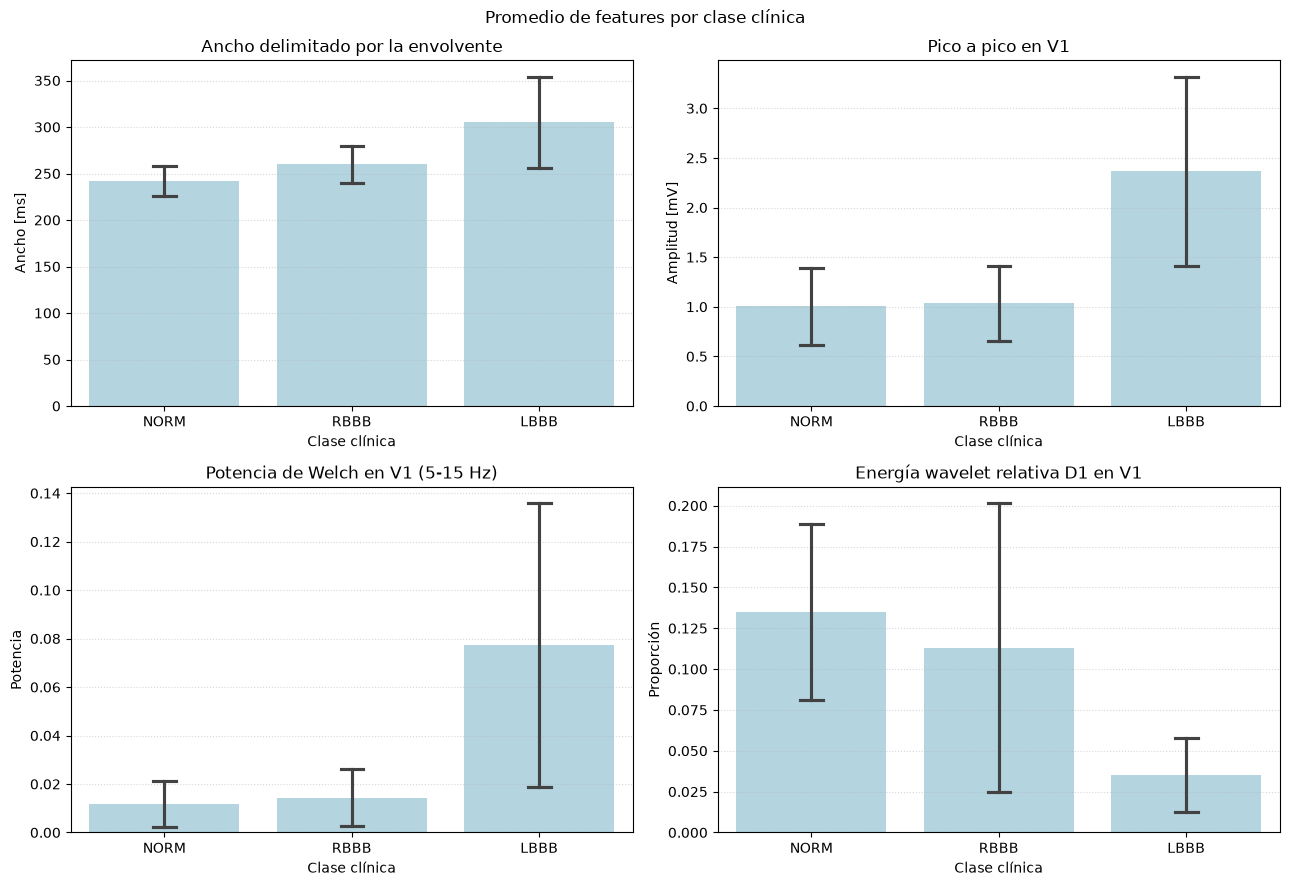

In [16]:
features_a_graficar = [
    (
        "ancho_envolvente_ms",
        "Ancho delimitado por la envolvente",
        "Ancho [ms]",
    ),
    ("V1_pico_a_pico", "Pico a pico en V1", "Amplitud [mV]"),
    (
        "V1_potencia_5_15hz",
        "Potencia de Welch en V1 (5-15 Hz)",
        "Potencia",
    ),
    (
        "V1_energia_relativa_D1",
        "Energía wavelet relativa D1 en V1",
        "Proporción",
    ),
]

fig, ejes = plt.subplots(2, 2, figsize=(13, 9))

for eje, (columna, titulo, unidad) in zip(
    ejes.ravel(), features_a_graficar
):
    sns.barplot(
        data=features_finales,
        x="clase_clinica",
        y=columna,
        order=CLASES,
        estimator=np.mean,
        errorbar="sd",
        capsize=0.12,
        color="lightblue",
        ax=eje,
    )
    eje.set_title(titulo)
    eje.set_xlabel("Clase clínica")
    eje.set_ylabel(unidad)
    eje.grid(axis="y", linestyle=":", alpha=0.5)

fig.suptitle("Promedio de features por clase clínica")
plt.tight_layout()
plt.show()


## 17. División por paciente y por base

**Qué hace:** Separa PTB-XL en entrenamiento y test interno sin compartir pacientes, y reserva CPSC como test externo.

**Por qué se hace:** La separación por paciente evita fuga de información; la separación por base evalúa generalización entre poblaciones.

**Resultado esperado:** Se crean X/y para entrenamiento, prueba interna y prueba externa, además del grupo de paciente usado en la validación cruzada.


In [17]:
desarrollo = features_finales[
    features_finales["base"] == BASE_DESARROLLO
].copy()
externo = features_finales[
    features_finales["base"] == BASE_EXTERNA
].copy()

division_interna = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)
indices_train, indices_test = next(division_interna.split(
    desarrollo,
    desarrollo["clase_clinica"],
    groups=desarrollo["patient_id"],
))

train = desarrollo.iloc[indices_train].copy()
test_interno = desarrollo.iloc[indices_test].copy()
test_externo = externo.copy()

metadata = [
    "id_registro",
    "patient_id",
    "base",
    "clase_clinica",
    "cantidad_qrs_promediados",
]
columnas_features = [
    columna
    for columna in features_finales.columns
    if columna not in metadata
]

X_train = train[columnas_features]
y_train = train["clase_clinica"]
grupos_train = train["patient_id"]
X_test_interno = test_interno[columnas_features]
y_test_interno = test_interno["clase_clinica"]
X_test_externo = test_externo[columnas_features]
y_test_externo = test_externo["clase_clinica"]

print("Entrenamiento PTB-XL:", len(X_train))
print("Test interno PTB-XL :", len(X_test_interno))
print("Test externo CPSC   :", len(X_test_externo))
print(
    "Pacientes compartidos:",
    len(set(train["patient_id"]) & set(test_interno["patient_id"])),
)
display(pd.DataFrame({
    "train": y_train.value_counts(),
    "test_interno": y_test_interno.value_counts(),
    "test_externo": y_test_externo.value_counts(),
}).fillna(0).astype(int))


Entrenamiento PTB-XL: 202
Test interno PTB-XL : 51
Test externo CPSC   : 295
Pacientes compartidos: 0


,train,test_interno,test_externo
clase_clinica,,,
LBBB,77,19,99
NORM,66,17,99
RBBB,59,15,97


## 18. Entrenamiento de Random Forest y MLP

**Qué hace:** Optimiza cuatro combinaciones sencillas por modelo mediante validación cruzada de tres partes, sin mezclar registros del mismo paciente.

**Por qué se hace:** Random Forest aporta interpretabilidad; la MLP representa el enfoque neuronal pedido por el anteproyecto. Agrupar por paciente evita una evaluación artificialmente optimista.

**Resultado esperado:** Quedan entrenados los mejores modelos según F1-macro.


In [18]:
pipeline_rf = Pipeline([
    ("imputador", SimpleImputer(strategy="median")),
    (
        "modelo",
        RandomForestClassifier(
            random_state=42,
            class_weight="balanced",
        ),
    ),
])
parametros_rf = {
    "modelo__n_estimators": [100, 200],
    "modelo__max_depth": [None, 10],
}

pipeline_mlp = Pipeline([
    ("imputador", SimpleImputer(strategy="median")),
    ("escalado", StandardScaler()),
    (
        "modelo",
        MLPClassifier(
            max_iter=1000,
            random_state=42,
        ),
    ),
])
parametros_mlp = {
    "modelo__hidden_layer_sizes": [(32,), (64, 32)],
    "modelo__alpha": [0.0001, 0.001],
}

validacion_cruzada = StratifiedGroupKFold(
    n_splits=3,
    shuffle=True,
    random_state=42,
)

modelo_rf = GridSearchCV(
    pipeline_rf,
    parametros_rf,
    cv=validacion_cruzada,
    scoring="f1_macro",
    n_jobs=-1,
)
modelo_mlp = GridSearchCV(
    pipeline_mlp,
    parametros_mlp,
    cv=validacion_cruzada,
    scoring="f1_macro",
    n_jobs=-1,
)

print("Entrenando Random Forest...")
modelo_rf.fit(X_train, y_train, groups=grupos_train)
print("Mejores parámetros RF:", modelo_rf.best_params_)

print("\nEntrenando MLP...")
modelo_mlp.fit(X_train, y_train, groups=grupos_train)
print("Mejores parámetros MLP:", modelo_mlp.best_params_)


Entrenando Random Forest...


Mejores parámetros RF: {'modelo__max_depth': None, 'modelo__n_estimators': 200}

Entrenando MLP...


Mejores parámetros MLP: {'modelo__alpha': 0.0001, 'modelo__hidden_layer_sizes': (32,)}


## 19. Evaluación interna y externa

**Qué hace:** Calcula F1-macro, AUC-ROC, reportes por clase y cuatro matrices de confusión.

**Por qué se hace:** Comparar el test interno con CPSC permite saber cuánto cambia el rendimiento al pasar a otra base.

**Resultado esperado:** Se obtiene una tabla final para Random Forest y MLP en ambas evaluaciones.



Random Forest - Interna (PTB-XL)
              precision    recall  f1-score   support

        LBBB       0.94      0.89      0.92        19
        NORM       0.88      0.82      0.85        17
        RBBB       0.71      0.80      0.75        15

    accuracy                           0.84        51
   macro avg       0.84      0.84      0.84        51
weighted avg       0.85      0.84      0.85        51


Random Forest - Externa (CPSC)
              precision    recall  f1-score   support

        LBBB       0.95      0.93      0.94        99
        NORM       0.85      0.80      0.82        99
        RBBB       0.75      0.81      0.78        97

    accuracy                           0.85       295
   macro avg       0.85      0.85      0.85       295
weighted avg       0.85      0.85      0.85       295


MLP - Interna (PTB-XL)
              precision    recall  f1-score   support

        LBBB       1.00      0.84      0.91        19
        NORM       0.82      0.82      

,modelo,evaluacion,F1-macro,AUC-ROC macro
0,Random Forest,Interna (PTB-XL),0.839,0.945
1,Random Forest,Externa (CPSC),0.848,0.960
2,MLP,Interna (PTB-XL),0.842,0.951
3,MLP,Externa (CPSC),0.830,0.951


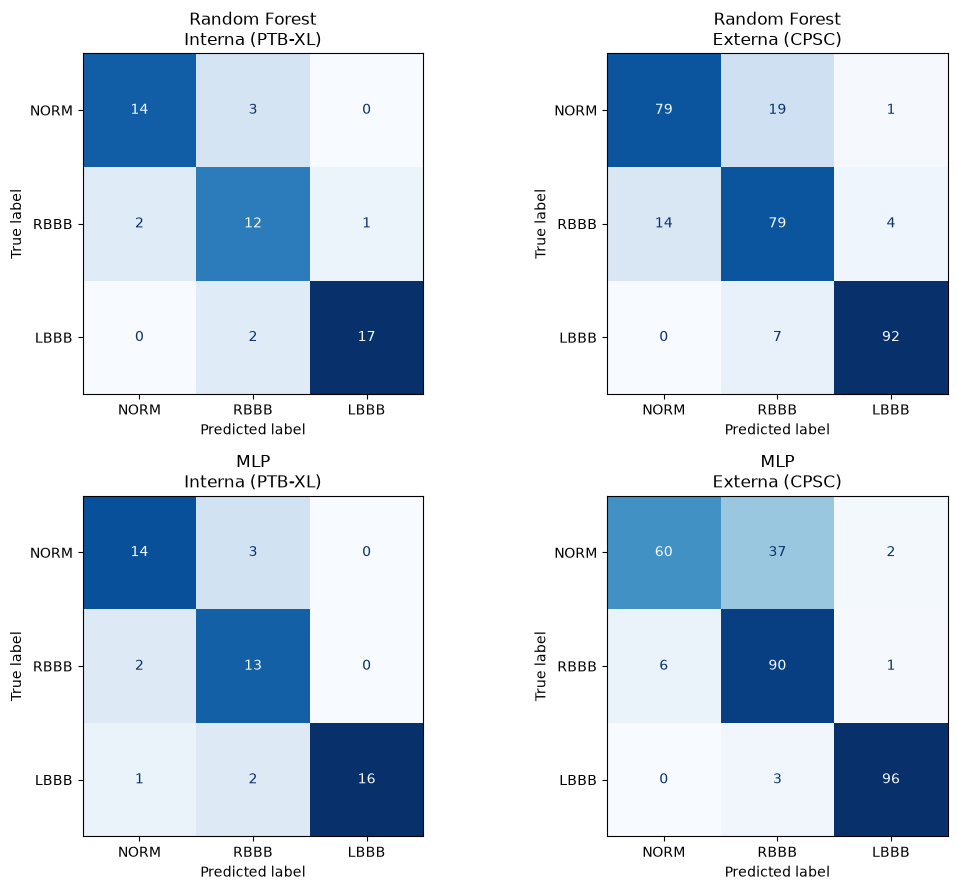

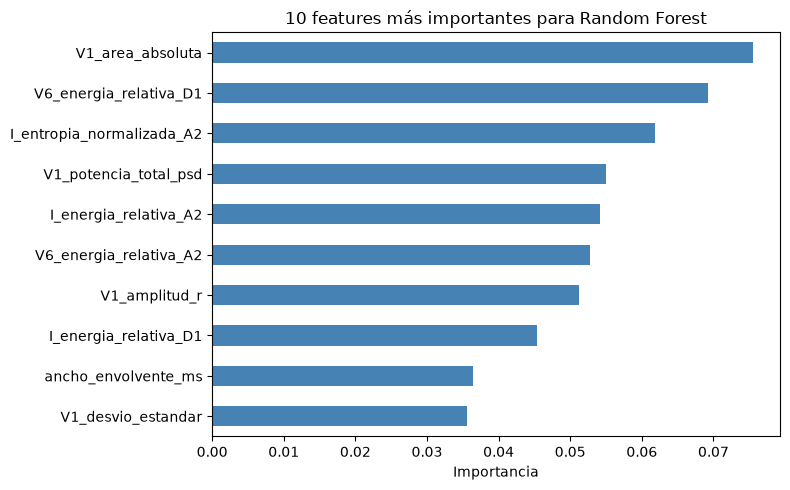

In [19]:
def evaluar(nombre, modelo, X, y, conjunto):
    prediccion = modelo.predict(X)
    probabilidades = modelo.predict_proba(X)

    f1 = f1_score(y, prediccion, average="macro")
    auc = roc_auc_score(
        y,
        probabilidades,
        multi_class="ovr",
        average="macro",
        labels=modelo.classes_,
    )

    print("\n" + "=" * 65)
    print(nombre, "-", conjunto)
    print(classification_report(y, prediccion, zero_division=0))

    fila = {
        "modelo": nombre,
        "evaluacion": conjunto,
        "F1-macro": f1,
        "AUC-ROC macro": auc,
    }
    return fila, prediccion


modelos = {
    "Random Forest": modelo_rf,
    "MLP": modelo_mlp,
}
conjuntos = {
    "Interna (PTB-XL)": (X_test_interno, y_test_interno),
    "Externa (CPSC)": (X_test_externo, y_test_externo),
}

filas_resultados = []
predicciones = {}

for nombre, modelo in modelos.items():
    for conjunto, (X, y) in conjuntos.items():
        fila, prediccion = evaluar(
            nombre, modelo, X, y, conjunto
        )
        filas_resultados.append(fila)
        predicciones[(nombre, conjunto)] = prediccion

resultados_finales = pd.DataFrame(filas_resultados)
display(resultados_finales.round(3))

fig, ejes = plt.subplots(2, 2, figsize=(11, 9))
for fila, (nombre, modelo) in enumerate(modelos.items()):
    for columna, (conjunto, (X, y)) in enumerate(conjuntos.items()):
        ConfusionMatrixDisplay.from_predictions(
            y,
            predicciones[(nombre, conjunto)],
            labels=CLASES,
            display_labels=CLASES,
            cmap="Blues",
            colorbar=False,
            ax=ejes[fila, columna],
        )
        ejes[fila, columna].set_title(nombre + "\n" + conjunto)

plt.tight_layout()
plt.show()

# Interpretabilidad del Random Forest.
importancias = pd.Series(
    modelo_rf.best_estimator_.named_steps["modelo"].feature_importances_,
    index=columnas_features,
).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
importancias.sort_values().plot(kind="barh", color="steelblue")
plt.title("10 features más importantes para Random Forest")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()


## 20. Cómo explicar el pipeline completo

1. **Armonización:** todas las bases se reducen a `NORM`, `RBBB` y
   `LBBB`, se seleccionan DI/V1/V6 y se remuestrean a 100 Hz.
2. **Filtrado:** Butterworth de 0,5 a 40 Hz elimina deriva y ruido.
3. **Pan-Tompkins:** derivada, cuadrado e integración convierten el
   QRS en una joroba de energía.
4. **Segmentación:** los cruces relativos de esa misma envolvente
   delimitan segmentos de duración variable.
5. **Calidad:** cada exclusión queda registrada con un motivo.
6. **Features:** morfología y DWT se calculan por QRS; Welch usa
   ventanas de 2 segundos del registro completo. La energía y la
   entropía wavelet se normalizan para comparar segmentos variables.
7. **Modelos:** Random Forest se compara con una red MLP.
8. **Validación:** PTB-XL se usa para desarrollo y CPSC como base
   externa independiente.

### Límites que deben declararse

- El ancho calculado corresponde a la ventana delimitada por la
  envolvente; no es una medición clínica exacta de la duración QRS.
- XQRS mide acuerdo entre dos detectores, no sensibilidad frente a
  anotaciones manuales verdaderas.
- La SNR usada para calidad es una estimación basada en el residuo
  del filtro.
- `MAX_REGISTROS_POR_CLASE = 100` convierte esta ejecución en una
  prueba piloto. Para el estudio final se debe usar `None`.
- Chapman-Shaoxing es opcional en el código, pero no estaba disponible
  en esta ejecución; los resultados actuales usan PTB-XL y CPSC.
